# Difference-in-Differences

ref.

https://theeffectbook.net/ch-DifferenceinDifference.html 

In [48]:
setwd("/Users/Local/statsproject")

In [49]:
source("src/functions_and_things.r")

load_libraries()

In [50]:
df_daily <- read.csv("data/clean/daily_ridership.csv")
head(df_daily)

,date,borough,ridership
,<chr>,<chr>,<int>
1,2024-06-03,Bronx,80011
2,2024-06-03,Brooklyn,259226
3,2024-06-03,Manhattan,314840
4,2024-06-03,Queens,173652
5,2024-06-04,Bronx,83027
6,2024-06-04,Brooklyn,282527


## summary stats for boroughs

In [51]:
weather_df <- read.csv("data/supplemental/weather.csv")

weather_df |> 
    rename(
        min_temp = TMIN, 
        snow     = SNOW,
        snow_d   = SNWD,
        rain     = PRCP) |> 
    mutate(date = as.Date(DATE), format = "%m-%d-%Y") |> 
    select(date, min_temp, snow, snow_d, rain) -> weather_df

In [52]:
df_borough <- data.frame(df_daily)

df_borough |> mutate(date = as.Date(date)) -> df_borough

head(df_borough)
head(weather_df)

,date,borough,ridership
,<date>,<chr>,<int>
1,2024-06-03,Bronx,80011
2,2024-06-03,Brooklyn,259226
3,2024-06-03,Manhattan,314840
4,2024-06-03,Queens,173652
5,2024-06-04,Bronx,83027
6,2024-06-04,Brooklyn,282527


,date,min_temp,snow,snow_d,rain
,<date>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-01,62,0,0,0.00
2,2024-06-02,62,0,0,0.00
3,2024-06-03,66,0,0,0.02
4,2024-06-04,64,0,0,0.00
5,2024-06-05,63,0,0,0.04
6,2024-06-06,69,0,0,0.58


In [53]:
df_borough |> left_join(weather_df, by = "date") -> df_borough

head(df_borough)

,date,borough,ridership,min_temp,snow,snow_d,rain
,<date>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,2024-06-03,Bronx,80011,66,0,0,0.02
2,2024-06-03,Brooklyn,259226,66,0,0,0.02
3,2024-06-03,Manhattan,314840,66,0,0,0.02
4,2024-06-03,Queens,173652,66,0,0,0.02
5,2024-06-04,Bronx,83027,64,0,0,0.00
6,2024-06-04,Brooklyn,282527,64,0,0,0.00


The following would make more sense if I had data that would differ between the boroughs 

In [54]:
df_borough |> filter(borough == "Manhattan") -> df_manhattan

df_borough |> filter(borough == "Brooklyn") -> df_brooklyn

In [55]:
stargazer(df_manhattan,
          type = "text", out = "borough stats",
          title = "Summary Statistics for Manhattan")

stargazer(df_brooklyn,
          type = "text", out = "borough stats",
          title = "Summary Statistics for Brooklyn")


Summary Statistics for Manhattan
Statistic  N     Mean      St. Dev.    Min     Max  
----------------------------------------------------
ridership 397 331,893.900 42,572.140 114,434 402,210
min_temp  397   52.446      15.629     12      81   
snow      397    0.008      0.079     0.000   1.300 
snow_d    394    0.036      0.256     0.000   3.100 
rain      397    0.087      0.239     0.000   1.960 
----------------------------------------------------

Summary Statistics for Brooklyn
Statistic  N     Mean      St. Dev.   Min     Max  
---------------------------------------------------
ridership 397 292,147.300 49,663.860 61,696 357,278
min_temp  397   52.446      15.629     12     81   
snow      397    0.008      0.079    0.000   1.300 
snow_d    394    0.036      0.256    0.000   3.100 
rain      397    0.087      0.239    0.000   1.960 
---------------------------------------------------


In [56]:
df_ma <- read.csv("data/clean/smooth.csv")

head(df_ma)

,week,borough,ridership
,<chr>,<chr>,<int>
1,2024-06-02,Bronx,404496
2,2024-06-02,Brooklyn,1328534
3,2024-06-02,Manhattan,1607339
4,2024-06-02,Queens,873184
5,2024-06-09,Bronx,408117
6,2024-06-09,Brooklyn,1314784


In [57]:
df_weekly <- read.csv("data/clean/weekly_ridership.csv")

df_weekly$week <- as.Date(df_weekly$week)

head(df_weekly)

,week,borough,ridership
,<date>,<chr>,<int>
1,2024-06-02,Bronx,404496
2,2024-06-02,Brooklyn,1328534
3,2024-06-02,Manhattan,1607339
4,2024-06-02,Queens,873184
5,2024-06-09,Bronx,408117
6,2024-06-09,Brooklyn,1314784


## Differince in Diff - effect book

### 18.2.1 - two way fixed effects

$$Y = \alpha_g + \alpha_t + \beta_1\text{Treated} + \epsilon$$

where 

$$
\begin{align*}
    Y &= ridership \\
    \alpha_g &= \text{treated or untreated}  \\
    \alpha_t &= \text{time period (treatment or not, post 2025)} \\
    \text{Treated} &= \text{binary variable, 1 if Manhattan after 2025}
\end{align*}
$$

"Two way fixed effects difference in differences estimator"

In [58]:
# treatment variable
df_daily |>
    mutate(
        date    = as.Date(date),
        Treated = (borough == "Manhattan") & (date > "2025-01-01")) -> df_daily

In [59]:
df_daily |> filter(borough == "Manhattan" | borough == "Brooklyn") -> df_daily_group

tail(df_daily_group)

,date,borough,ridership,Treated
,<date>,<chr>,<int>,<lgl>
789,2025-12-05,Brooklyn,305392,FALSE
790,2025-12-05,Manhattan,308337,TRUE
791,2025-12-08,Brooklyn,315190,FALSE
792,2025-12-08,Manhattan,315970,TRUE
793,2025-12-09,Brooklyn,326045,FALSE
794,2025-12-09,Manhattan,311322,TRUE


In [60]:
check <- (df_daily$borough == "Manhattan" & df_daily$Treated == "FALSE")
sum(check)

[1] 153

In [93]:
# foels 
clfe <- feols(ridership ~ Treated | borough + date, data = df_daily_group)

msummary(clfe, stars = c('*' = .1, '**' = .05, '***' = .01), 
    out = "latex", title = "Two way fixed effects")

\begin{table}
\centering
\begin{talltblr}[         %% tabularray outer open
caption={Two way fixed effects},
note{}={* p \num{< 0.1}, ** p \num{< 0.05}, *** p \num{< 0.01}},
]                     %% tabularray outer close
{                     %% tabularray inner open
colspec={Q[]Q[]},
hline{2}={1-2}{solid, black, 0.05em},
hline{4}={1-2}{solid, black, 0.05em},
hline{1}={1-2}{solid, black, 0.08em},
hline{14}={1-2}{solid, black, 0.08em},
column{2}={}{halign=c},
column{1}={}{halign=l},
}                     %% tabularray inner close
& (1) \\
TreatedTRUE & \num{-20206.267}*** \\
& (\num{1447.835}) \\
Num.Obs. & \num{794} \\
R2 & \num{0.981} \\
R2 Adj. & \num{0.961} \\
R2 Within & \num{0.330} \\
R2 Within Adj. & \num{0.329} \\
AIC & \num{17111.4} \\
BIC & \num{18977.6} \\
RMSE & \num{7002.25} \\
FE: borough & X \\
FE: date & X \\
\end{talltblr}
\end{table} 

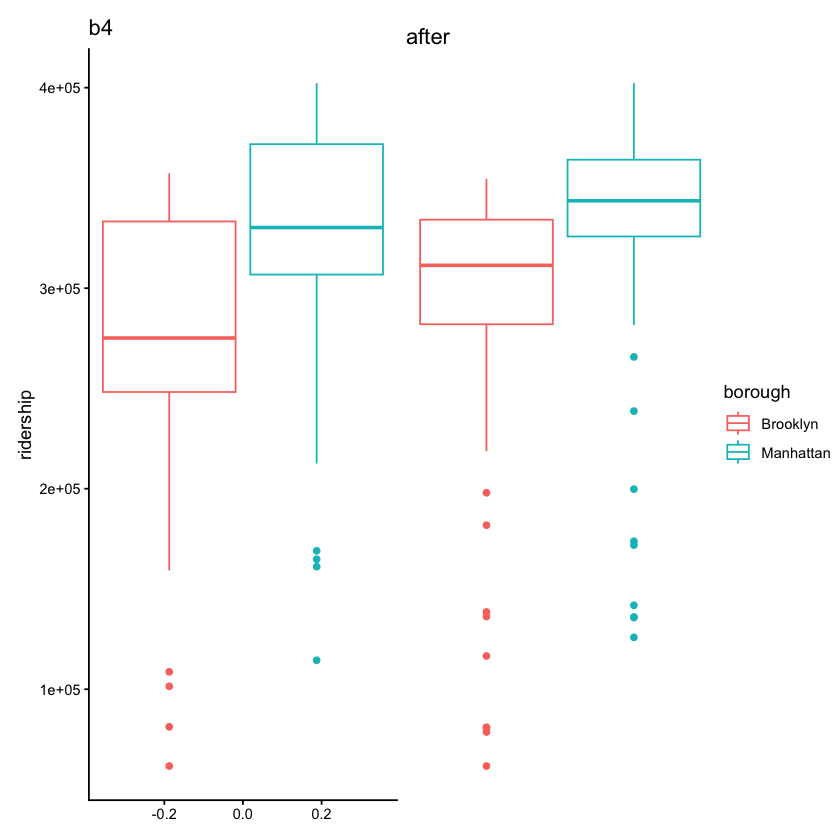

In [64]:
df_daily_group |> filter(date < "2025-01-01") |> 
ggplot(aes(y = ridership, color = borough)) + 
    geom_boxplot() + theme_classic() +
    theme(legend.position = "none") + labs(title = "b4")-> before

df_daily_group |> filter(date > "2025-01-01") |> 
ggplot(aes(y = ridership, color = borough)) + 
    geom_boxplot() + theme_void() + 
    labs(title = "after") -> after

before + after

### 18.2.3 supporting parallel trends?


$$Y = \alpha_g + \beta_1 Time + \beta_2 Time * Group + \epsilon$$

Are the trends different?

In [72]:
p_reg <- lm(ridership ~ date + borough + date:borough, data = df_daily_group)
summary(p_reg)


Call:
lm(formula = ridership ~ date + borough + date:borough, data = df_daily_group)

Residuals:
    Min      1Q  Median      3Q     Max 
-225864  -17583    5043   29711   73317 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)           -1.003e+06  2.882e+05  -3.479 0.000530 ***
date                   6.425e+01  1.430e+01   4.493 8.06e-06 ***
boroughManhattan       1.574e+06  4.076e+05   3.863 0.000121 ***
date:boroughManhattan -7.614e+01  2.022e+01  -3.765 0.000179 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 45710 on 790 degrees of freedom
Multiple R-squared:  0.1779,	Adjusted R-squared:  0.1748 
F-statistic: 56.98 on 3 and 790 DF,  p-value: < 2.2e-16


## Placebo (fake treatment)

### Fake treatment date

In [ ]:
fake = "2024-9-01"

df_daily_group |> 
    mutate(Treated_fake_time    = (borough == "Manhattan") & (date > fake),
           Treated_fake_borough = (borough == "Brooklyn") & (date > as.Date("2025-01-01"))) -> df_daily_group 

tail(df_daily_group)

,date,borough,ridership,Treated,Treated_fake,Treated_fake_time,Treated_fake_borough
,<date>,<chr>,<int>,<lgl>,<lgl>,<lgl>,<lgl>
789,2025-12-05,Brooklyn,305392,FALSE,FALSE,FALSE,TRUE
790,2025-12-05,Manhattan,308337,TRUE,TRUE,TRUE,FALSE
791,2025-12-08,Brooklyn,315190,FALSE,FALSE,FALSE,TRUE
792,2025-12-08,Manhattan,315970,TRUE,TRUE,TRUE,FALSE
793,2025-12-09,Brooklyn,326045,FALSE,FALSE,FALSE,TRUE
794,2025-12-09,Manhattan,311322,TRUE,TRUE,TRUE,FALSE


In [67]:
check2 <- (df_daily_group$borough == "Manhattan" & df_daily_group$Treated_fake == "FALSE")
sum(check2)

[1] 65

In [68]:
install.packages("kableExtra")


The downloaded binary packages are in
	/var/folders/9n/xcff1phn0m54z30p0b7kb0k00000gn/T//RtmpBPskLN/downloaded_packages


In [78]:
# foels fake

# pre-real treatment data

clfe_fake <- feols(ridership ~ Treated_fake | borough + date, data = df_daily_group)

# .../genAI_logs/chatGPT_tableformat_code.pdf 
# before 
# msummary(list(clfe, clfe_fake), stars = c('*' = .1, '**' = .05, '***' = .01))

# after
#msummary(list(clfe, clfe_fake), 
#    stars = c('*' = .1, '**' = .05, '***' = .01), # CHATGPT part, 
#    output = "latex")

### Fake treatment Borough

"Another way to do this if you have multiple untreated groups is to use all of the data, but drop the data from the treated groups. Then, assign different untreated groups to be fake treated groups, and estimate the DID effect for them"

In [85]:
df_daily |> filter(borough == "Queens" | borough == "Brooklyn") -> fake_groups 

fake_groups |> 
    mutate(Treated_borough_fake  = (borough == "Queens") & 
          (date > as.Date("2025-01-01"))) -> fake_groups

head(fake_groups)

check2 <- (fake_groups$borough == "Queens" & fake_groups$Treated_borough_fake == "TRUE")
sum(check2)

,date,borough,ridership,Treated,Treated_borough_fake
,<date>,<chr>,<int>,<lgl>,<lgl>
1,2024-06-03,Brooklyn,259226,FALSE,FALSE
2,2024-06-03,Queens,173652,FALSE,FALSE
3,2024-06-04,Brooklyn,282527,FALSE,FALSE
4,2024-06-04,Queens,180056,FALSE,FALSE
5,2024-06-05,Brooklyn,281214,FALSE,FALSE
6,2024-06-05,Queens,179095,FALSE,FALSE


[1] 244

In [ ]:
clfe_fake_borough <- feols(ridership ~ Treated_borough_fake | borough + date, data = fake_groups)

In [90]:
modelsummary(
  list("Real"            = clfe,
       "Placebo Time"    = clfe_fake, 
       "Placebo Borough" = clfe_fake_borough),
  stars = TRUE, out = "latex")

\begin{table}
\centering
\begin{talltblr}[         %% tabularray outer open
entry=none,label=none,
note{}={+ p \num{< 0.1}, * p \num{< 0.05}, ** p \num{< 0.01}, *** p \num{< 0.001}},
]                     %% tabularray outer close
{                     %% tabularray inner open
colspec={Q[]Q[]Q[]Q[]},
hline{2}={1-4}{solid, black, 0.05em},
hline{8}={1-4}{solid, black, 0.05em},
hline{1}={1-4}{solid, black, 0.08em},
hline{18}={1-4}{solid, black, 0.08em},
column{2-4}={}{halign=c},
column{1}={}{halign=l},
}                     %% tabularray inner close
& Real & Placebo Time & Placebo Borough \\
TreatedTRUE & \num{-20206.267}*** &  &  \\
& (\num{1447.835}) &  &  \\
Treated\_fakeTRUE &  & \num{-24166.208}*** &  \\
&  & (\num{1983.934}) &  \\
Treated\_borough\_fakeTRUE &  &  & \num{-25607.514}*** \\
&  &  & (\num{2644.938}) \\
Num.Obs. & \num{794} & \num{794} & \num{794} \\
R2 & \num{0.981} & \num{0.979} & \num{0.963} \\
R2 Adj. & \num{0.961} & \num{0.958} & \num{0.926} \\
R2 Within & \num{0.33

## Diff in diff by hand

https://evalf22.classes.andrewheiss.com/example/diff-in-diff.html